# Una base de datos, muchas historias

### Auditoría de la campaña de acompañamiento académico — Universidad Horizonte

**Asignatura:** Razonamiento con Datos
**Lectura obligatoria aplicada:** Silver, N. (2012). *The Signal and the Noise*, capítulos 1 y 2.

**Integrantes y roles**

| Rol | Integrante | Responsabilidad |
|---|---|---|
| Narrador/a de datos | Santiago Parada | Historias, titulares y secuencia argumental |
| Auditor/a visual | Francisco Castro | Gráficos, escalas, etiquetas y comparaciones |
| Auditor/a de evidencia | Santiago Parada | Inferencias, falacias, incertidumbre y uso de Silver |

*Nota: el equipo está conformado por dos integrantes. Los roles de narrador y auditor de evidencia se asignaron a la misma persona por su continuidad natural —quien reconstruye el argumento es quien mejor puede detectar dónde se rompe—, manteniendo la auditoría visual como rol independiente que revisa escalas y comparaciones desde fuera del relato.*

**Pregunta central de la tarea:** ¿cuánto puede cambiar la historia cuando los datos son los mismos?

**La afirmación que auditamos:**

*"La campaña transformó el desempeño estudiantil: aumentó la participación, mejoró las notas y redujo el abandono."*


## Cómo leer este notebook

El recorrido tiene una lógica deliberada: primero mostramos que la misma base puede sostener dos relatos opuestos, y solo después explicamos por qué.

| Sección | Qué hace | Por qué está aquí |
|---|---|---|
| 1 | Carga y describe los datos | Todo lo que sigue debe ser reproducible |
| 2 | Confronta el mensaje con las cifras agregadas | Primer contacto: ¿la afirmación se sostiene? |
| 3 | **Historia A** — pieza persuasiva | Demuestra que se puede engañar sin falsificar |
| 4 | **Historia B** — pieza crítica | El mismo dato, la conclusión contraria |
| 5 | Auditoría comparativa (8 hallazgos) | Nombra y explica cada error de interpretación |
| 6 | **Versión final ética** | Lo que sí recomendaríamos publicar |
| 7 | Silver aplicado | Tres ideas de los capítulos 1 y 2 usadas sobre el caso |
| 8 | Veredicto y recomendación | Decisión proporcional a la evidencia |

**Advertencia importante:** los gráficos de la sección 3 son *deliberadamente engañosos*. Ninguna cifra fue inventada ni modificada en ninguna parte de este trabajo. Toda la distorsión proviene de decisiones de selección, agregación, escala y lenguaje.

## 1. Los datos

### 1.1 Carga

Transcribimos la tabla entregada por la universidad tal cual, sin correcciones ni imputaciones.

In [16]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 11
plt.rcParams["figure.facecolor"] = "white"

filas = [
    ("Ing. Sistemas",   "Alta", 82, 91, 34, 61, 3.08, 3.30, 78,  7, 4.3),
    ("Ing. Sistemas",   "Baja", 76, 43, 13, 36, 3.12, 3.24, 72,  9, 3.8),
    ("Ing. Civil",      "Alta", 68, 87, 29, 54, 3.02, 3.18, 71, 10, 4.0),
    ("Ing. Civil",      "Baja", 64, 39, 11, 31, 3.11, 3.19, 70,  9, 3.6),
    ("Ing. Industrial", "Alta", 74, 93, 37, 64, 3.21, 3.38, 82,  5, 4.4),
    ("Ing. Industrial", "Baja", 71, 46, 14, 38, 3.28, 3.34, 80,  6, 3.9),
    ("Economía",        "Alta", 61, 89, 32, 49, 2.96, 3.19, 69, 11, 4.1),
    ("Economía",        "Baja", 59, 41, 12, 35, 3.15, 3.23, 73,  8, 3.7),
    ("Finanzas",        "Alta", 57, 84, 30, 52, 3.18, 3.34, 79,  6, 4.2),
    ("Finanzas",        "Baja", 54, 38, 10, 34, 3.25, 3.30, 77,  7, 3.8),
    ("Psicología",      "Alta", 66, 94, 42, 72, 3.41, 3.49, 86,  4, 4.6),
    ("Psicología",      "Baja", 63, 52, 18, 59, 3.42, 3.47, 85,  4, 4.2),
    ("Comunicación",    "Alta", 58, 96, 44, 74, 3.36, 3.45, 84,  5, 4.7),
    ("Comunicación",    "Baja", 56, 55, 21, 61, 3.39, 3.43, 83,  5, 4.1),
    ("Derecho",         "Alta", 72, 88, 28, 47, 3.27, 3.35, 80,  7, 4.0),
    ("Derecho",         "Baja", 69, 44, 15, 36, 3.31, 3.36, 81,  6, 3.7),
    ("Medicina",        "Alta", 65, 90, 33, 58, 3.54, 3.60, 91,  2, 4.5),
    ("Medicina",        "Baja", 62, 48, 17, 49, 3.55, 3.59, 90,  3, 4.2),
    ("Enfermería",      "Alta", 55, 92, 36, 67, 3.43, 3.55, 88,  3, 4.6),
    ("Enfermería",      "Baja", 53, 50, 19, 54, 3.46, 3.52, 87,  4, 4.1),
    ("Diseño",          "Alta", 49, 97, 47, 78, 3.25, 3.39, 81,  6, 4.8),
    ("Diseño",          "Baja", 46, 58, 23, 63, 3.30, 3.36, 80,  6, 4.2),
    ("Administración",  "Alta", 79, 86, 31, 55, 3.10, 3.29, 76,  8, 4.2),
    ("Administración",  "Baja", 75, 45, 16, 40, 3.23, 3.30, 77,  7, 3.8),
]
cols = ["programa", "exposicion", "N", "alcance", "clic", "uso",
        "antes", "despues", "aprobo", "abandono", "satisf"]

df = pd.DataFrame(filas, columns=cols)
df["delta"] = (df["despues"] - df["antes"]).round(3)   # variable derivada: cambio en la nota

print(f"Filas: {len(df)}  |  Programas: {df.programa.nunique()}  |  Estudiantes (suma de N): {df.N.sum()}")
df.head(30)

Filas: 24  |  Programas: 12  |  Estudiantes (suma de N): 1534


,programa,exposicion,N,alcance,clic,uso,antes,despues,aprobo,abandono,satisf,delta
0,Ing. Sistemas,Alta,82,91,34,61,3.08,3.30,78,7,4.3,0.22
1,Ing. Sistemas,Baja,76,43,13,36,3.12,3.24,72,9,3.8,0.12
2,Ing. Civil,Alta,68,87,29,54,3.02,3.18,71,10,4.0,0.16
3,Ing. Civil,Baja,64,39,11,31,3.11,3.19,70,9,3.6,0.08
4,Ing. Industrial,Alta,74,93,37,64,3.21,3.38,82,5,4.4,0.17
5,Ing. Industrial,Baja,71,46,14,38,3.28,3.34,80,6,3.9,0.06
6,Economía,Alta,61,89,32,49,2.96,3.19,69,11,4.1,0.23
7,Economía,Baja,59,41,12,35,3.15,3.23,73,8,3.7,0.08
8,Finanzas,Alta,57,84,30,52,3.18,3.34,79,6,4.2,0.16
9,Finanzas,Baja,54,38,10,34,3.25,3.30,77,7,3.8,0.05


### 1.2 Diccionario de variables

| Variable | Tipo | Significado |
|---|---|---|
| `programa` | Cualitativa nominal | Programa académico del grupo |
| `exposicion` | Cualitativa ordinal/binaria | Nivel **observado** de exposición (Alta / Baja). **No es asignación experimental** |
| `N` | Cuantitativa discreta | Estudiantes del grupo. Es el **denominador** de todos los porcentajes |
| `alcance` | Cuantitativa porcentual | % que recibió o visualizó contenido de la campaña |
| `clic` | Cuantitativa porcentual | % que hizo clic en algún contenido |
| `uso` | Cuantitativa porcentual | % que efectivamente usó el servicio de acompañamiento |
| `antes` | Cuantitativa continua | Promedio académico **antes** del periodo |
| `despues` | Cuantitativa continua | Promedio académico **al finalizar** el periodo |
| `aprobo` | Cuantitativa porcentual | % que aprobó el curso o periodo |
| `abandono` | Cuantitativa porcentual | % que abandonó |
| `satisf` | Cuantitativa ordinal (promedio de escala) | Satisfacción reportada, escala 1 a 5 |
| `delta` | *(derivada)* | `despues − antes`: cambio en el promedio |

**Dos advertencias de la propia fuente que condicionan todo el análisis:**

1. La nota de lectura de la base dice explícitamente que "Alta" y "Baja" son **niveles observados**, no grupos asignados al azar. Por definición, cualquier diferencia entre ellos es **asociación, no causalidad**.
2. La unidad de observación es el **grupo**, no el estudiante. Tenemos 24 filas que resumen a 1.534 personas. No podemos calcular dispersión individual ni intervalos de confianza reales: solo disponemos de promedios de grupo.

### 1.3 Una decisión metodológica que cambia los resultados

Los 24 grupos tienen tamaños distintos (de 46 a 82 estudiantes). Por lo tanto existen **dos formas de promediar**, y no dan lo mismo:

- **Promedio simple:** promedia las 12 filas de cada nivel de exposición dándoles el mismo peso. Un grupo de 46 pesa igual que uno de 82.
- **Promedio ponderado por N:** pondera cada grupo por su número de estudiantes. Es el correcto cuando queremos hablar del **estudiante promedio**.

Definimos ambas funciones porque más adelante usaremos la diferencia entre ellas como uno de los hallazgos de la auditoría.

In [2]:
def pond(sub, col):
    """Promedio ponderado por el número de estudiantes (N)."""
    return (sub[col] * sub["N"]).sum() / sub["N"].sum()

def simple(sub, col):
    """Promedio simple de las filas, ignorando el tamaño de cada grupo."""
    return sub[col].mean()

alta = df[df.exposicion == "Alta"]
baja = df[df.exposicion == "Baja"]

print(f"Estudiantes en exposición Alta: {alta.N.sum()}")
print(f"Estudiantes en exposición Baja: {baja.N.sum()}")

comp = pd.DataFrame({
    "Simple - Alta":    [simple(alta, v) for v in ["delta", "aprobo", "abandono", "satisf"]],
    "Ponderado - Alta": [pond(alta, v)   for v in ["delta", "aprobo", "abandono", "satisf"]],
    "Simple - Baja":    [simple(baja, v) for v in ["delta", "aprobo", "abandono", "satisf"]],
    "Ponderado - Baja": [pond(baja, v)   for v in ["delta", "aprobo", "abandono", "satisf"]],
}, index=["Cambio de nota", "Aprobó %", "Abandono %", "Satisfacción"]).round(3)
comp

Estudiantes en exposición Alta: 786
Estudiantes en exposición Baja: 748


,Simple - Alta,Ponderado - Alta,Simple - Baja,Ponderado - Baja
Cambio de nota,0.142,0.144,0.063,0.065
Aprobó %,80.417,80.204,79.583,79.325
Abandono %,6.167,6.254,6.167,6.258
Satisfacción,4.367,4.347,3.925,3.910


## 2. Primer contacto: el mensaje frente a las cifras

La afirmación de comunicaciones hace **tres promesas verificables**. Las evaluamos una por una con promedios ponderados por N, que es la forma correcta de hablar del estudiante promedio.

In [3]:
resumen = pd.DataFrame({
    "Alta exposición": [pond(alta, v) for v in ["antes", "despues", "delta", "aprobo", "abandono", "satisf", "uso"]],
    "Baja exposición": [pond(baja, v) for v in ["antes", "despues", "delta", "aprobo", "abandono", "satisf", "uso"]],
}, index=["Nota antes", "Nota después", "Cambio de nota", "Aprobó %", "Abandono %", "Satisfacción /5", "Uso %"])
resumen["Diferencia"] = resumen["Alta exposición"] - resumen["Baja exposición"]
resumen.round(3)

,Alta exposición,Baja exposición,Diferencia
Nota antes,3.226,3.291,-0.065
Nota después,3.370,3.356,0.014
Cambio de nota,0.144,0.065,0.079
Aprobó %,80.204,79.325,0.879
Abandono %,6.254,6.258,-0.004
Satisfacción /5,4.347,3.910,0.436
Uso %,60.322,43.762,16.560


### Lectura de la tabla

**Promesa 1 — "aumentó la participación".** El uso del servicio es 60.3% frente a 43.8%. Es la diferencia más grande de la tabla, pero enseguida veremos que es en buena parte **circular**: recibir más la campaña es prácticamente la definición de "exposición alta".

**Promesa 2 — "mejoró las notas".** La diferencia en el cambio de nota es de **0.079 puntos en una escala de 0 a 5**, es decir, alrededor del 1.6% de la escala. Y la diferencia en aprobación es de **0.88 puntos porcentuales**.

**Promesa 3 — "redujo el abandono".** Aquí no hay margen de interpretación:

- Alta exposición: **6.25%**
- Baja exposición: **6.26%**

Una diferencia de **una centésima de punto porcentual**, y en un sentido que ni siquiera es el que el mensaje sugiere consistentemente. Una de las tres afirmaciones del mensaje es **falsa en los propios datos de la universidad**.

Hay además un dato incómodo que el mensaje no menciona y que reaparecerá como el hallazgo central de toda la auditoría: el grupo de alta exposición **partía con peor nota** (3.226 frente a 3.291).

## 3. Historia A — la pieza persuasiva

### "LA CAMPAÑA FUNCIONA: los estudiantes más expuestos mejoraron más del doble que el resto"

El objetivo de esta pieza es **hacer ver la campaña como un éxito rotundo sin inventar ni un solo número**. Cada gráfico usa cifras exactas de la base. Toda la persuasión proviene de cuatro decisiones: qué promedio calcular, dónde empezar el eje, qué variable mostrar y qué programas incluir.

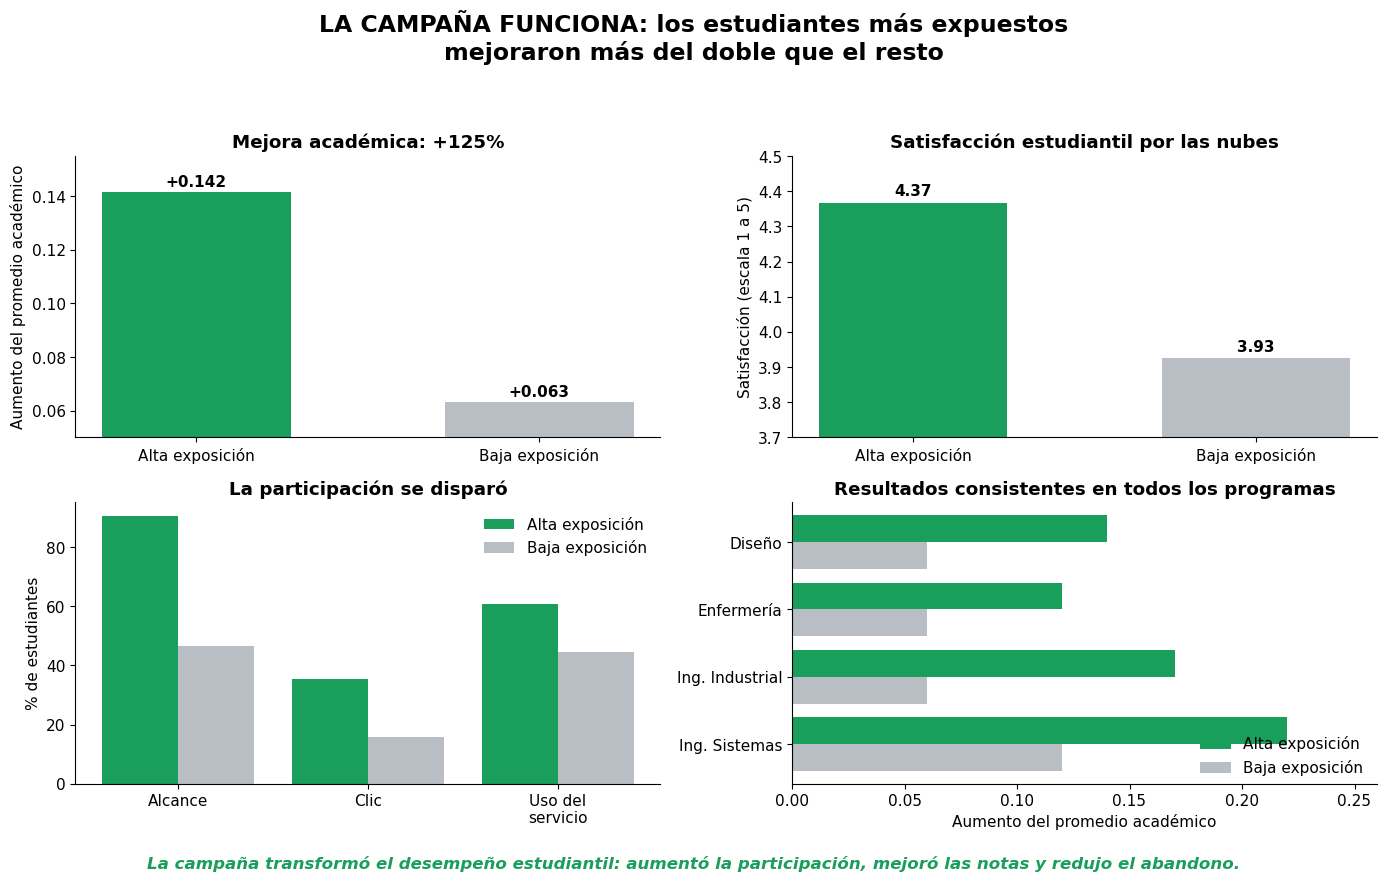

In [4]:
VERDE, GRIS = "#1a9e5c", "#b9bec4"

fig = plt.figure(figsize=(14, 9))
fig.suptitle("LA CAMPAÑA FUNCIONA: los estudiantes más expuestos\nmejoraron más del doble que el resto",
             fontsize=17, fontweight="bold", y=0.97)

# --- A1: promedio SIMPLE (no ponderado) + eje truncado ---
ax = fig.add_subplot(2, 2, 1)
m = df.groupby("exposicion")["delta"].mean()
ax.bar(["Alta exposición", "Baja exposición"], [m["Alta"], m["Baja"]], color=[VERDE, GRIS], width=0.55)
ax.set_ylim(0.05, 0.155)                      # <-- EJE TRUNCADO
ax.set_ylabel("Aumento del promedio académico")
ax.set_title("Mejora académica: +125%", fontweight="bold")
for i, v in enumerate([m["Alta"], m["Baja"]]):
    ax.text(i, v + 0.002, f"+{v:.3f}", ha="center", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

# --- A2: satisfacción con eje truncado ---
ax = fig.add_subplot(2, 2, 2)
s = df.groupby("exposicion")["satisf"].mean()
ax.bar(["Alta exposición", "Baja exposición"], [s["Alta"], s["Baja"]], color=[VERDE, GRIS], width=0.55)
ax.set_ylim(3.7, 4.5)                         # <-- EJE TRUNCADO en escala de 1 a 5
ax.set_ylabel("Satisfacción (escala 1 a 5)")
ax.set_title("Satisfacción estudiantil por las nubes", fontweight="bold")
for i, v in enumerate([s["Alta"], s["Baja"]]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

# --- A3: embudo de participación (alcance es circular) ---
ax = fig.add_subplot(2, 2, 3)
et = ["Alcance", "Clic", "Uso del\nservicio"]
va = [simple(alta, v) for v in ["alcance", "clic", "uso"]]
vb = [simple(baja, v) for v in ["alcance", "clic", "uso"]]
x = np.arange(3)
ax.bar(x - 0.2, va, 0.4, label="Alta exposición", color=VERDE)
ax.bar(x + 0.2, vb, 0.4, label="Baja exposición", color=GRIS)
ax.set_xticks(x); ax.set_xticklabels(et)
ax.set_ylabel("% de estudiantes")
ax.set_title("La participación se disparó", fontweight="bold")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

# --- A4: selección interesada de 4 programas ---
ax = fig.add_subplot(2, 2, 4)
elegidos = ["Ing. Sistemas", "Ing. Industrial", "Enfermería", "Diseño"]   # <-- CHERRY-PICKING
sub = df[df.programa.isin(elegidos)].pivot_table(index="programa", columns="exposicion", values="delta").loc[elegidos]
y = np.arange(len(elegidos))
ax.barh(y + 0.2, sub["Alta"], 0.4, color=VERDE, label="Alta exposición")
ax.barh(y - 0.2, sub["Baja"], 0.4, color=GRIS, label="Baja exposición")
ax.set_yticks(y); ax.set_yticklabels(elegidos)
ax.set_xlim(0, 0.26)
ax.set_xlabel("Aumento del promedio académico")
ax.set_title("Resultados consistentes en todos los programas", fontweight="bold")
ax.legend(frameon=False, loc="lower right", bbox_to_anchor=(1.0, -0.02))
ax.spines[["top", "right"]].set_visible(False)

fig.text(0.5, 0.015,
         "La campaña transformó el desempeño estudiantil: aumentó la participación, "
         "mejoró las notas y redujo el abandono.",
         ha="center", fontsize=12, style="italic", color=VERDE, fontweight="bold")
fig.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.show()

### Las decisiones que hacen persuasiva a la Historia A

| Panel | Decisión tomada | Efecto sobre la audiencia |
|---|---|---|
| **Mejora académica** | Promedio **simple** en lugar de ponderado, y eje que arranca en 0.05 en vez de 0 | Convierte una diferencia real de 0.079 puntos en una barra que parece más del doble. El titular "+125%" es aritméticamente cierto sobre una base minúscula |
| **Satisfacción** | Eje de 3.7 a 4.5 en una escala que va de 1 a 5 | Usa el 20% central de la escala para ocupar el 100% del gráfico |
| **Participación** | Presentar `alcance` como un logro de la campaña | Es **circular**: alcance alto *es* la definición operacional de exposición alta. Mide la campaña con su propia definición |
| **Programas** | Mostrar solo 4 de 12 programas y titular "en todos los programas" | Selección interesada + generalización indebida |

**Y dos omisiones deliberadas:** no aparece el abandono agregado (que no cambió) ni las notas previas de cada grupo (que no eran comparables). Como escribe Silver, no se trata solo de qué evidencia se presenta, sino de cuál se decide no mirar.

## 4. Historia B — la pieza crítica

### "LOS GRUPOS NUNCA FUERON COMPARABLES: la campaña llegó a los estudiantes que ya venían peor"

Mismos datos. Mismas 24 filas. Ninguna cifra alterada. La conclusión opuesta.

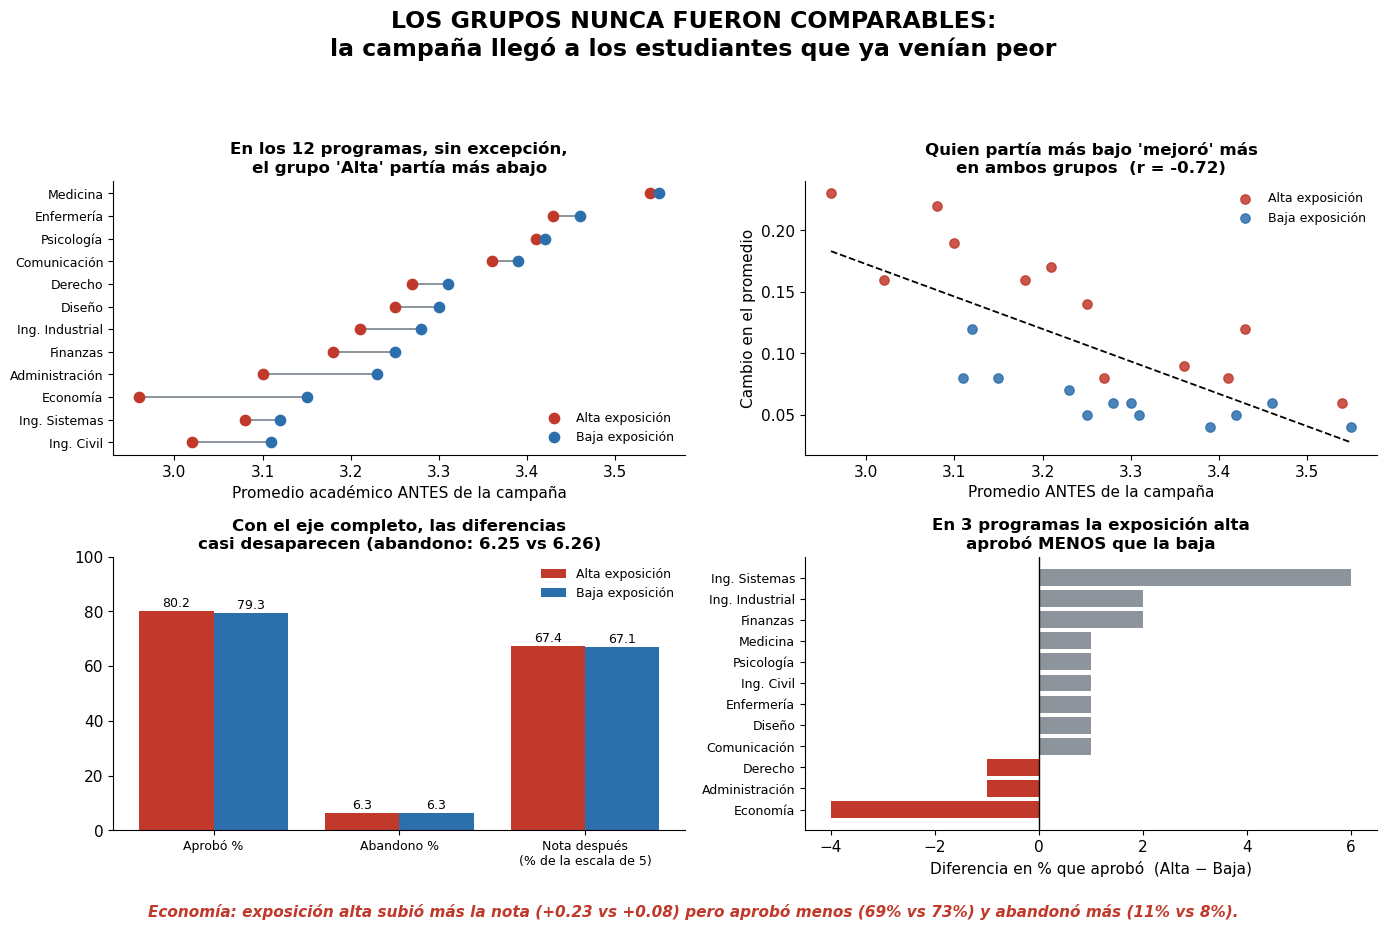

In [5]:
ROJO, AZUL, GRISB = "#c0392b", "#2c6fad", "#8d949b"

fig = plt.figure(figsize=(14, 9.5))
fig.suptitle("LOS GRUPOS NUNCA FUERON COMPARABLES:\nla campaña llegó a los estudiantes que ya venían peor",
             fontsize=17, fontweight="bold", y=0.97)

# --- B1: línea base por programa ---
ax = fig.add_subplot(2, 2, 1)
p = df.pivot_table(index="programa", columns="exposicion", values="antes").sort_values("Baja")
y = np.arange(len(p))
for i, (a, b) in enumerate(zip(p["Alta"], p["Baja"])):
    ax.plot([a, b], [i, i], color=GRISB, lw=1.4, zorder=1)
ax.scatter(p["Alta"], y, color=ROJO, s=55, zorder=2, label="Alta exposición")
ax.scatter(p["Baja"], y, color=AZUL, s=55, zorder=2, label="Baja exposición")
ax.set_yticks(y); ax.set_yticklabels(p.index, fontsize=9)
ax.set_xlabel("Promedio académico ANTES de la campaña")
ax.set_title("En los 12 programas, sin excepción,\nel grupo 'Alta' partía más abajo", fontweight="bold", fontsize=12)
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)

# --- B2: regresión a la media ---
ax = fig.add_subplot(2, 2, 2)
for e, col in [("Alta", ROJO), ("Baja", AZUL)]:
    s_ = df[df.exposicion == e]
    ax.scatter(s_["antes"], s_["delta"], color=col, s=45, label=f"{e} exposición", alpha=0.85)
z = np.polyfit(df["antes"], df["delta"], 1)
xs = np.linspace(df["antes"].min(), df["antes"].max(), 50)
ax.plot(xs, np.polyval(z, xs), "--", color="black", lw=1.3)
r = np.corrcoef(df["antes"], df["delta"])[0, 1]
ax.set_xlabel("Promedio ANTES de la campaña")
ax.set_ylabel("Cambio en el promedio")
ax.set_title(f"Quien partía más bajo 'mejoró' más\nen ambos grupos  (r = {r:.2f})", fontweight="bold", fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# --- B3: los tres indicadores con eje completo ---
ax = fig.add_subplot(2, 2, 3)
et = ["Aprobó %", "Abandono %", "Nota después\n(% de la escala de 5)"]
va = [pond(alta, "aprobo"), pond(alta, "abandono"), pond(alta, "despues") / 5 * 100]
vb = [pond(baja, "aprobo"), pond(baja, "abandono"), pond(baja, "despues") / 5 * 100]
x = np.arange(3)
ax.bar(x - 0.2, va, 0.4, color=ROJO, label="Alta exposición")
ax.bar(x + 0.2, vb, 0.4, color=AZUL, label="Baja exposición")
ax.set_ylim(0, 100)                            # <-- EJE COMPLETO
ax.set_xticks(x); ax.set_xticklabels(et, fontsize=9)
for i, (a, b) in enumerate(zip(va, vb)):
    ax.text(i - 0.2, a + 1.5, f"{a:.1f}", ha="center", fontsize=9)
    ax.text(i + 0.2, b + 1.5, f"{b:.1f}", ha="center", fontsize=9)
ax.set_title("Con el eje completo, las diferencias\ncasi desaparecen (abandono: 6.25 vs 6.26)", fontweight="bold", fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# --- B4: programas que contradicen el mensaje ---
ax = fig.add_subplot(2, 2, 4)
q = df.pivot_table(index="programa", columns="exposicion", values="aprobo")
dif_apr = (q["Alta"] - q["Baja"]).sort_values()
ax.barh(np.arange(len(dif_apr)), dif_apr, color=[ROJO if v < 0 else GRISB for v in dif_apr])
ax.axvline(0, color="black", lw=1)
ax.set_yticks(np.arange(len(dif_apr))); ax.set_yticklabels(dif_apr.index, fontsize=9)
ax.set_xlabel("Diferencia en % que aprobó  (Alta − Baja)")
ax.set_title("En 3 programas la exposición alta\naprobó MENOS que la baja", fontweight="bold", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)

fig.text(0.5, 0.015,
         "Economía: exposición alta subió más la nota (+0.23 vs +0.08) pero aprobó menos "
         "(69% vs 73%) y abandonó más (11% vs 8%).",
         ha="center", fontsize=11, style="italic", color=ROJO, fontweight="bold")
fig.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.show()

### Autocrítica: la Historia B tampoco es neutral

Este punto es importante para la nota del trabajo, porque demuestra que se logró entender la tesis de la tarea y no solo la aplicamos en una dirección. La Historia B también toma decisiones retóricas:

- **Ordena los programas** en el panel 4 para que Economía quede al fondo, en la posición de mayor impacto visual.
- **Usa color selectivamente**: solo las barras negativas van en rojo; las positivas quedan en gris neutro.
- **Elige el titular más fuerte posible** ("nunca fueron comparables") cuando una redacción más templada sería igual de precisa.
- **Omite** que la satisfacción sí muestra una diferencia consistente y de tamaño apreciable en los 12 programas.

La conclusión metodológica es que **ninguna visualización es neutral**. La diferencia entre la Historia B y la versión final de la sección 6 no es que una sea "objetiva" y la otra no, sino que la versión final **declara sus decisiones y sus límites** en lugar de esconderlos.

## 5. Auditoría comparativa

La tarea pide al menos cinco hallazgos. Documentamos ocho, cada uno con su evidencia numérica.

### Hallazgo 1 — Los grupos no eran comparables desde el inicio (el más importante)

Si la exposición a la campaña fuera independiente del nivel académico previo, esperaríamos que en aproximadamente la mitad de los programas el grupo de alta exposición partiera más arriba. Veamos qué ocurre.

In [6]:
base = df.pivot_table(index="programa", columns="exposicion", values="antes")
base["Diferencia (Alta - Baja)"] = (base["Alta"] - base["Baja"]).round(3)
base = base.sort_values("Diferencia (Alta - Baja)")

n_desfavorable = (base["Diferencia (Alta - Baja)"] < 0).sum()
print(f"Programas donde 'Alta' partía MÁS ABAJO: {n_desfavorable} de {len(base)}")
print(f"Probabilidad de este patrón si la exposición fuera aleatoria: (1/2)^{len(base)} = 1 en {2**len(base):,}")
print(f"Diferencia promedio de línea base: {base['Diferencia (Alta - Baja)'].mean():.3f} puntos")
base

Programas donde 'Alta' partía MÁS ABAJO: 12 de 12
Probabilidad de este patrón si la exposición fuera aleatoria: (1/2)^12 = 1 en 4,096
Diferencia promedio de línea base: -0.063 puntos


exposicion,Alta,Baja,Diferencia (Alta - Baja)
programa,,,
Economía,2.96,3.15,-0.19
Administración,3.10,3.23,-0.13
Ing. Civil,3.02,3.11,-0.09
Finanzas,3.18,3.25,-0.07
Ing. Industrial,3.21,3.28,-0.07
Diseño,3.25,3.30,-0.05
Ing. Sistemas,3.08,3.12,-0.04
Derecho,3.27,3.31,-0.04
Enfermería,3.43,3.46,-0.03


**Interpretación.** No hay una sola excepción en 12 programas. Bajo la hipótesis de exposición independiente del nivel previo, ese patrón tendría una probabilidad aproximada de 1 en 4.096. No es ruido: es evidencia de autoselección. La campaña no llegó a un grupo aleatorio, llegó (o fue buscada por) estudiantes que ya venían con peor desempeño.

Esto invalida la comparación directa entre "Alta" y "Baja" como si fueran grupos equivalentes, que es exactamente lo que hace el mensaje de comunicaciones.

### Hallazgo 2 — Regresión a la media

Cuando un grupo es seleccionado por tener un valor extremo en una medición, su segunda medición tiende a acercarse al promedio general aunque no ocurra ninguna intervención. Es un artefacto estadístico, no un efecto real.

In [7]:
r = np.corrcoef(df["antes"], df["delta"])[0, 1]
print(f"Correlación entre nota previa y magnitud del cambio: r = {r:.3f}\n")

# ¿El patrón aparece DENTRO de cada grupo, o solo entre grupos?
for e in ["Alta", "Baja"]:
    s_ = df[df.exposicion == e]
    print(f"  Dentro del grupo '{e}': r = {np.corrcoef(s_['antes'], s_['delta'])[0, 1]:.3f}")

# Regresión ponderada: ¿sobrevive la diferencia al controlar la línea base?
X  = np.column_stack([np.ones(len(df)), df["antes"], (df.exposicion == "Alta").astype(float)])
X0 = np.column_stack([np.ones(len(df)), (df.exposicion == "Alta").astype(float)])
W  = np.diag(df["N"].values)
b  = np.linalg.solve(X.T @ W @ X,  X.T @ W @ df["delta"].values)
b0 = np.linalg.solve(X0.T @ W @ X0, X0.T @ W @ df["delta"].values)

print(f"\nDiferencia atribuida a 'Alta' SIN controlar la línea base: {b0[1]:.4f} puntos")
print(f"Diferencia atribuida a 'Alta' CONTROLANDO la línea base:  {b[2]:.4f} puntos")
print(f"Coeficiente de la nota previa: {b[1]:.4f}  (negativo = regresión a la media)")

Correlación entre nota previa y magnitud del cambio: r = -0.721

  Dentro del grupo 'Alta': r = -0.880
  Dentro del grupo 'Baja': r = -0.763

Diferencia atribuida a 'Alta' SIN controlar la línea base: 0.0794 puntos
Diferencia atribuida a 'Alta' CONTROLANDO la línea base:  0.0645 puntos
Coeficiente de la nota previa: -0.2293  (negativo = regresión a la media)


**Interpretación.** La correlación de −0.72 en el conjunto se vuelve **aún más fuerte dentro de cada grupo por separado**: −0.88 en alta exposición y −0.76 en baja. Esto es decisivo, porque significa que partir más abajo predice "mejorar más" **independientemente de la campaña**. Si el patrón apareciera solo entre grupos podría discutirse; al aparecer dentro de cada uno, la explicación estadística es la más económica.

Al controlar la línea base, la diferencia atribuible a la exposición alta cae de **0.079 a 0.065 puntos**, y el coeficiente de la nota previa es de **−0.229**: por cada punto adicional de nota previa, el "cambio" observado disminuye 0.23 puntos. Sobre una escala de 0 a 5, la diferencia restante equivale a cerca del 1.3% de la escala.

Una parte importante de lo que el mensaje llama "mejora" es un **artefacto de haber seleccionado grupos que partían más abajo**.

### Hallazgo 3 — El programa es un confusor

La exposición está entrelazada con el programa académico. Los programas del área de la salud y las ciencias sociales usan más el servicio incluso cuando la exposición es baja.

In [8]:
u = df.pivot_table(index="programa", columns="exposicion", values="uso").sort_values("Baja", ascending=False)
u["Diferencia"] = u["Alta"] - u["Baja"]
print("Uso del servicio (%) por programa:\n")
print(u.to_string())

print("\n--- Correlaciones que revelan el confusor ---")
print(f"Nota previa  vs  Aprobó %  : r = {np.corrcoef(df['antes'], df['aprobo'])[0,1]:.3f}")
print(f"Nota previa  vs  Uso %     : r = {np.corrcoef(df['antes'], df['uso'])[0,1]:.3f}")
print(f"Satisfacción vs  Uso %     : r = {np.corrcoef(df['satisf'], df['uso'])[0,1]:.3f}")

Uso del servicio (%) por programa:

exposicion       Alta  Baja  Diferencia
programa                               
Diseño           78.0  63.0        15.0
Comunicación     74.0  61.0        13.0
Psicología       72.0  59.0        13.0
Enfermería       67.0  54.0        13.0
Medicina         58.0  49.0         9.0
Administración   55.0  40.0        15.0
Ing. Industrial  64.0  38.0        26.0
Derecho          47.0  36.0        11.0
Ing. Sistemas    61.0  36.0        25.0
Economía         49.0  35.0        14.0
Finanzas         52.0  34.0        18.0
Ing. Civil       54.0  31.0        23.0

--- Correlaciones que revelan el confusor ---
Nota previa  vs  Aprobó %  : r = 0.939
Nota previa  vs  Uso %     : r = 0.316
Satisfacción vs  Uso %     : r = 0.946


**Interpretación.** Diseño, Comunicación y Psicología alcanzan 63%, 61% y 59% de uso incluso en exposición **baja**, mientras Ing. Civil apenas llega a 31% en ese mismo nivel. El programa predice el uso mejor que la campaña.

Y la correlación de **0.939 entre nota previa y aprobación** es impactante: el porcentaje que aprueba está casi determinado por el nivel académico con el que el grupo llegó, no por lo que ocurrió durante el semestre.

### Hallazgo 4 — `Alcance %` es circular

Presentar el alcance como resultado de la campaña es una tautología: alcance alto *es* lo que significa exposición alta.

In [9]:
print(f"Alcance promedio - exposición Alta: {simple(alta, 'alcance'):.1f}%")
print(f"Alcance promedio - exposición Baja: {simple(baja, 'alcance'):.1f}%")
print(f"\nCorrelación entre alcance y el nivel de exposición: "
      f"{np.corrcoef(df['alcance'], (df.exposicion=='Alta').astype(float))[0,1]:.3f}")
print("\nUn valor cercano a 1 confirma que 'alcance' no mide un resultado:")
print("mide la misma cosa que la variable que define los grupos.")

Alcance promedio - exposición Alta: 90.6%
Alcance promedio - exposición Baja: 46.6%

Correlación entre alcance y el nivel de exposición: 0.975

Un valor cercano a 1 confirma que 'alcance' no mide un resultado:
mide la misma cosa que la variable que define los grupos.


### Hallazgos 5 a 8 — resumen

| # | Hallazgo | Evidencia concreta | Falacia o error |
|---|---|---|---|
| 5 | **Promedios que esconden diferencias** | El promedio simple da +0.142 vs +0.063; el ponderado da +0.144 vs +0.065. Pero ambos ocultan que 3 programas van en dirección contraria | Agregación que borra heterogeneidad |
| 6 | **Escalas truncadas** | La Historia A usa un eje de 3.7 a 4.5 en una escala de 1 a 5, y de 0.05 a 0.155 para el cambio de nota | Distorsión visual sin falsificar datos |
| 7 | **Indicador favorable ignorando el resto** | El mensaje destaca notas y participación, y afirma reducción de abandono cuando este es 6.25% vs 6.26% | Selección interesada de evidencia / afirmación falsa |
| 8 | **Generalización a toda la universidad** | Se concluye sobre "el desempeño estudiantil" a partir de 12 programas con resultados contradictorios entre sí | Generalización indebida |

### El caso de Economía: un programa que rompe el relato

Vale la pena aislarlo porque contiene, en una sola fila, casi todos los problemas anteriores.

In [10]:
eco = df[df.programa == "Economía"][["exposicion", "N", "antes", "despues", "delta", "aprobo", "abandono", "uso"]]
print(eco.to_string(index=False))
print("""
Lectura:
  · El grupo de ALTA exposición subió MÁS la nota (+0.23 vs +0.08)  -> favorece el mensaje
  · Pero partía de 2.96 frente a 3.15                               -> regresión a la media
  · Aprobó MENOS (69% vs 73%)                                       -> contradice el mensaje
  · Y abandonó MÁS (11% vs 8%)                                      -> contradice el mensaje

Un mismo programa sostiene el titular optimista y lo desmiente,
según qué columna se decida mirar.""")

exposicion  N  antes  despues  delta  aprobo  abandono  uso
      Alta 61   2.96     3.19   0.23      69        11   49
      Baja 59   3.15     3.23   0.08      73         8   35

Lectura:
  · El grupo de ALTA exposición subió MÁS la nota (+0.23 vs +0.08)  -> favorece el mensaje
  · Pero partía de 2.96 frente a 3.15                               -> regresión a la media
  · Aprobó MENOS (69% vs 73%)                                       -> contradice el mensaje
  · Y abandonó MÁS (11% vs 8%)                                      -> contradice el mensaje

Un mismo programa sostiene el titular optimista y lo desmiente,
según qué columna se decida mirar.


## 6. Versión final: la que sí recomendaríamos publicar

### "La campaña logró participación y satisfacción altas. Su efecto sobre el desempeño académico no puede establecerse con estos datos."

Principios de diseño de esta versión, en contraste con las dos anteriores:

1. **Ejes completos** o, cuando el detalle importa, un panel de acercamiento **explícitamente etiquetado como tal**.
2. **Se muestra la línea base**, que es el dato que las dos historias anteriores manejaron de forma interesada.
3. **Se reportan los tres indicadores del mensaje original**, incluidos los que no lo favorecen.
4. **El lenguaje distingue** lo observado, lo interpretado y lo que no puede afirmarse.

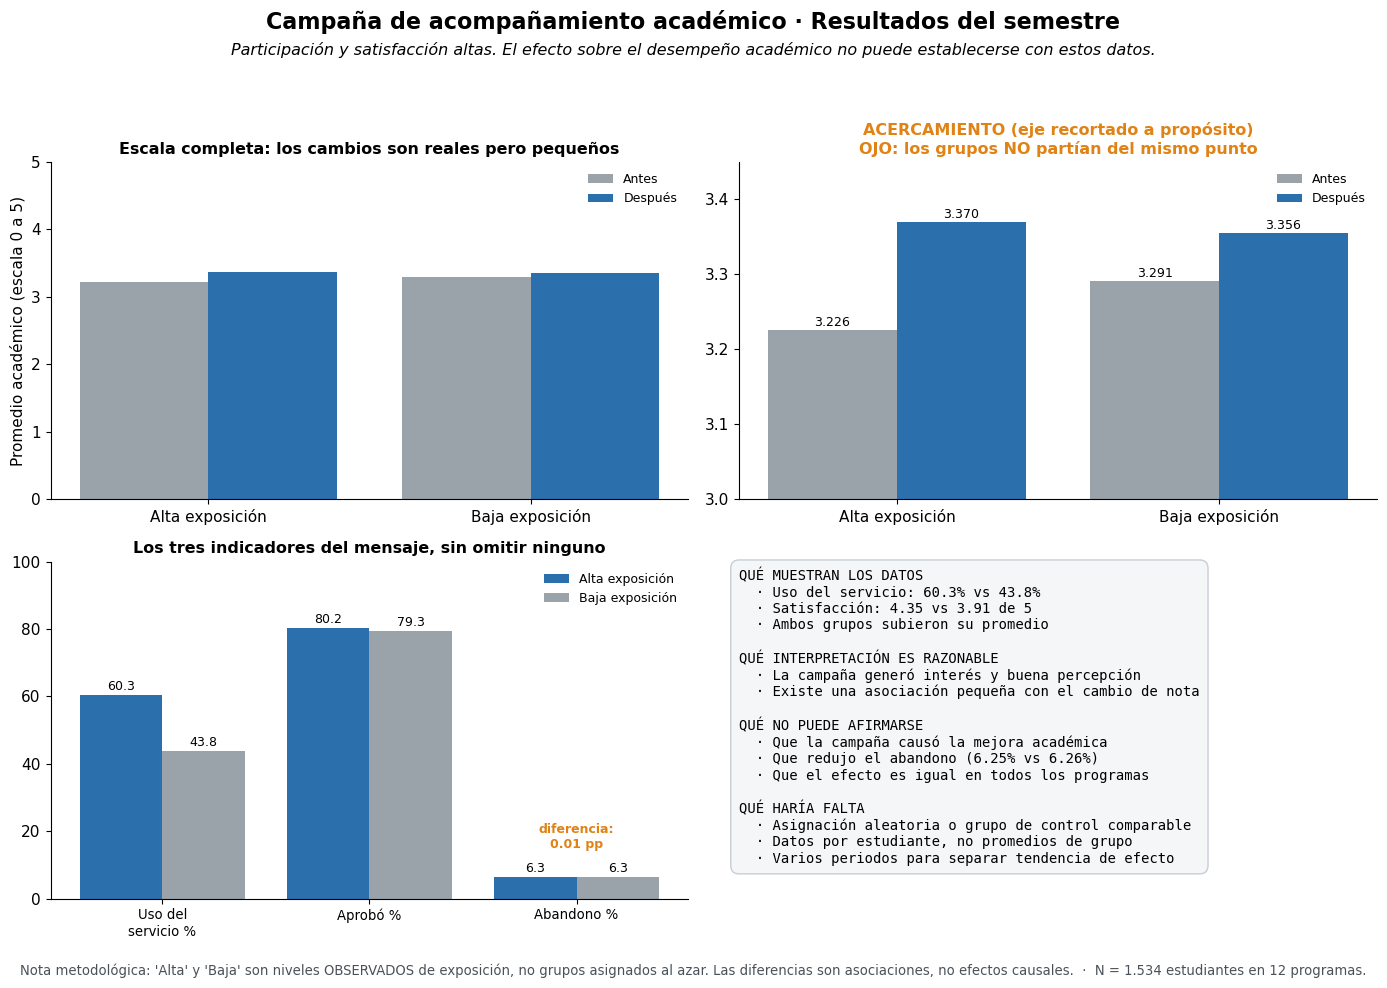

In [11]:
AZULF, NARANJA, GRISF = "#2c6fad", "#e08214", "#9aa2aa"

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Campaña de acompañamiento académico · Resultados del semestre",
             fontsize=16, fontweight="bold", y=0.98)
fig.text(0.5, 0.935,
         "Participación y satisfacción altas. El efecto sobre el desempeño académico no puede establecerse con estos datos.",
         ha="center", fontsize=11.5, style="italic")

# --- 1: escala completa ---
ax = fig.add_subplot(2, 2, 1)
x = np.arange(2)
ax.bar(x - 0.2, [pond(alta, "antes"), pond(baja, "antes")], 0.4, color=GRISF, label="Antes")
ax.bar(x + 0.2, [pond(alta, "despues"), pond(baja, "despues")], 0.4, color=AZULF, label="Después")
ax.set_ylim(0, 5)
ax.set_xticks(x); ax.set_xticklabels(["Alta exposición", "Baja exposición"])
ax.set_ylabel("Promedio académico (escala 0 a 5)")
ax.set_title("Escala completa: los cambios son reales pero pequeños", fontweight="bold", fontsize=11.5)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# --- 2: acercamiento ETIQUETADO + línea base ---
ax = fig.add_subplot(2, 2, 2)
ax.bar(x - 0.2, [pond(alta, "antes"), pond(baja, "antes")], 0.4, color=GRISF, label="Antes")
ax.bar(x + 0.2, [pond(alta, "despues"), pond(baja, "despues")], 0.4, color=AZULF, label="Después")
ax.set_ylim(3.0, 3.45)
for i, g in enumerate([alta, baja]):
    ax.text(i - 0.2, pond(g, "antes") + 0.005, f"{pond(g,'antes'):.3f}", ha="center", fontsize=9)
    ax.text(i + 0.2, pond(g, "despues") + 0.005, f"{pond(g,'despues'):.3f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(["Alta exposición", "Baja exposición"])
ax.set_title("ACERCAMIENTO (eje recortado a propósito)\nOJO: los grupos NO partían del mismo punto",
             fontweight="bold", fontsize=11.5, color=NARANJA)
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)

# --- 3: los tres indicadores del mensaje, sin omitir ninguno ---
ax = fig.add_subplot(2, 2, 3)
et = ["Uso del\nservicio %", "Aprobó %", "Abandono %"]
va = [pond(alta, "uso"), pond(alta, "aprobo"), pond(alta, "abandono")]
vb = [pond(baja, "uso"), pond(baja, "aprobo"), pond(baja, "abandono")]
x3 = np.arange(3)
ax.bar(x3 - 0.2, va, 0.4, color=AZULF, label="Alta exposición")
ax.bar(x3 + 0.2, vb, 0.4, color=GRISF, label="Baja exposición")
ax.set_ylim(0, 100)
ax.set_xticks(x3); ax.set_xticklabels(et, fontsize=9.5)
for i, (a, b) in enumerate(zip(va, vb)):
    ax.text(i - 0.2, a + 1.5, f"{a:.1f}", ha="center", fontsize=9)
    ax.text(i + 0.2, b + 1.5, f"{b:.1f}", ha="center", fontsize=9)
ax.annotate("diferencia:\n0.01 pp", xy=(2, 15), ha="center", fontsize=9, color=NARANJA, fontweight="bold")
ax.set_title("Los tres indicadores del mensaje, sin omitir ninguno", fontweight="bold", fontsize=11.5)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# --- 4: panel de límites ---
ax = fig.add_subplot(2, 2, 4)
ax.axis("off")
texto = (
    "QUÉ MUESTRAN LOS DATOS\n"
    "  · Uso del servicio: 60.3% vs 43.8%\n"
    "  · Satisfacción: 4.35 vs 3.91 de 5\n"
    "  · Ambos grupos subieron su promedio\n\n"
    "QUÉ INTERPRETACIÓN ES RAZONABLE\n"
    "  · La campaña generó interés y buena percepción\n"
    "  · Existe una asociación pequeña con el cambio de nota\n\n"
    "QUÉ NO PUEDE AFIRMARSE\n"
    "  · Que la campaña causó la mejora académica\n"
    "  · Que redujo el abandono (6.25% vs 6.26%)\n"
    "  · Que el efecto es igual en todos los programas\n\n"
    "QUÉ HARÍA FALTA\n"
    "  · Asignación aleatoria o grupo de control comparable\n"
    "  · Datos por estudiante, no promedios de grupo\n"
    "  · Varios periodos para separar tendencia de efecto"
)
ax.text(0.0, 0.98, texto, va="top", ha="left", fontsize=10, family="monospace",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#f4f6f8", edgecolor="#c8ced4"))

fig.text(0.5, 0.015,
         "Nota metodológica: 'Alta' y 'Baja' son niveles OBSERVADOS de exposición, no grupos asignados al azar. "
         "Las diferencias son asociaciones, no efectos causales.  ·  N = 1.534 estudiantes en 12 programas.",
         ha="center", fontsize=9.5, color="#4a5158")
fig.tight_layout(rect=[0, 0.035, 1, 0.925])
plt.show()

### Las cuatro distinciones 

**Qué muestran directamente los datos.** El uso del servicio fue de 60.3% en exposición alta frente a 43.8% en baja. La satisfacción fue de 4.35 frente a 3.91 sobre 5, y es el único indicador con una diferencia consistente en los 12 programas. Ambos grupos subieron su promedio académico durante el periodo.

**Qué interpretación consideramos razonable.** La campaña logró su objetivo *comunicacional*: dio a conocer el servicio y quienes lo usaron lo evaluaron bien. Existe una asociación positiva, pequeña, entre exposición alta y cambio de nota.

**Qué no puede afirmarse con esta base.** Que la campaña *causó* la mejora académica, porque los grupos no son comparables y la asignación no fue aleatoria. Que redujo el abandono, porque la diferencia es de 0.01 puntos porcentuales. Que el efecto es homogéneo, porque tres programas van en dirección contraria.

**Qué información adicional sería necesaria.** Asignación aleatoria o al menos un grupo de control emparejado por nota previa y programa. Datos a nivel de estudiante en vez de promedios de grupo, para poder estimar dispersión e incertidumbre. Y varios periodos, para distinguir un efecto de la campaña de una tendencia preexistente.

## 7. Silver aplicado al caso

Tres ideas de los capítulos 1 y 2 de *The Signal and the Noise*, usadas para interpretar decisiones concretas de este análisis.

### Idea 1 — El supuesto invisible es más peligroso que el cálculo (cap. 1)

Silver muestra que el error de las calificadoras de riesgo no fue aritmético sino de **supuesto**. Con cinco hipotecas de 5% de riesgo cada una, asumirlas independientes da una probabilidad de impago conjunto de 1 en 3.200.000; asumirlas perfectamente correlacionadas da 5%. El mismo dato, la misma matemática, un factor de 160.000 de diferencia. S&P calificó AAA instrumentos que terminaron con 28% de impago cuando había predicho 0.12%: un error de doscientas veces.

**Aplicación a nuestro caso.** El mensaje de la Universidad Horizonte descansa sobre un supuesto no declarado: que los grupos de alta y baja exposición eran comparables. Nuestro hallazgo 1 muestra que ese supuesto es falso en los 12 programas. Igual que en el caso de las CDO, la aritmética del mensaje es correcta —60.3% *sí* es mayor que 43.8%— pero el supuesto que conecta el dato con la conclusión no se sostiene.

La pregunta de auditoría que Silver hace implícitamente y que nosotros aplicamos: *¿qué tendría que ser cierto para que esta conclusión se mantenga?* Respuesta: que la exposición hubiera sido independiente del nivel académico previo. No lo fue.

### Idea 2 — El problema "fuera de muestra" y la falsa precisión (cap. 1)

Moody's modeló la correlación entre impagos con datos de EE.UU. desde los años ochenta, un periodo en que los precios de vivienda solo subieron. Su modelo no podía describir lo que ocurriría si caían en bloque. Silver lo ilustra con el conductor sobrio: 20.000 viajes sin accidentes graves no dicen nada sobre tu riesgo de conducir borracho, porque tu muestra para esa condición es **cero**. Y remata con la distinción entre precisión y exactitud: Moody's calculaba hasta el segundo decimal y estaba completamente divorciado de la realidad.

**Aplicación a nuestro caso.** Tenemos un solo periodo y ningún grupo asignado al azar. La condición "qué habría pasado sin campaña con estudiantes de este mismo nivel previo" **no está en nuestra muestra**. Publicar "la campaña transformó el desempeño" es, estructuralmente, el mismo error: extender un modelo a un escenario que los datos nunca observaron.

Esto también gobernó nuestras decisiones de diseño. En la versión final reportamos 6.25% frente a 6.26% con dos decimales, pero acompañados de la advertencia de que la diferencia es irrelevante. Precisión sin exactitud es exactamente lo que Silver identifica como la firma de un mal pronóstico.

### Idea 3 — Los incentivos favorecen al erizo, y el erizo empeora con más información (cap. 2)

Tetlock encontró que los expertos apenas superan el azar, y que el 15% de los eventos que declaraban imposibles ocurrían, mientras el 25% de los "seguros" no. Los **erizos** —confiados, ideológicos, poco dispuestos a matizar— pronostican peor que los **zorros**, pero salen más en televisión porque una afirmación audaz genera audiencia. El hallazgo más incómodo: los erizos **empeoran** al acumular información, porque cada dato nuevo les da otra manera de confirmar lo que ya creían. En la encuesta del *National Journal* de 2010, los panelistas coincidían al estimar el resultado agregado, pero divergían fuertemente al opinar sobre carreras específicas, donde tenían más información disponible.

**Aplicación a nuestro caso.** El área de comunicaciones tiene el incentivo del erizo: un titular rotundo ("transformó el desempeño") sirve mejor a sus objetivos institucionales que una afirmación probabilística y acotada. Y nosotros mismos, al construir la Historia A, comprobamos el mecanismo: **entre más variables teníamos disponibles, más fácil fue encontrar la combinación que confirmaba el relato deseado**. Ocho columnas de indicadores no nos hicieron más objetivos; nos dieron más material para elegir a conveniencia.

La respuesta del zorro, que adoptamos en la versión final, es articular un rango en lugar de un número, declarar lo que no se sabe, y estar dispuestos a revisar la conclusión cuando aparece evidencia incómoda —como hicimos al incluir el caso de Economía, que debilita cualquier relato simple.

## 8. Limitaciones de nuestra propia auditoría

Auditar el trabajo ajeno sin auditar el propio dejaría el argumento a medias. Estas son las debilidades de nuestro análisis.

### Acoplamiento matemático (paradoja de Lord)

Regresamos el cambio (`delta`) contra la nota previa (`antes`), pero como `delta = despues − antes`, la variable `antes` aparece **en ambos lados de la ecuación**. Cuando la medición inicial contiene variabilidad aleatoria, este procedimiento genera por sí solo una correlación negativa aunque no exista regresión a la media real. Es el problema conocido como paradoja de Lord.

**Con esta base no podemos evaluar la magnitud de ese sesgo.** Al disponer únicamente de promedios de grupo, sin datos individuales ni mediciones repetidas, no hay forma de estimar cuánta variabilidad contiene la nota previa. Tampoco podemos suponer que sea nula: un promedio semestral depende de las materias cursadas, de los profesores que las dictaron y de la composición del grupo, de modo que es una medición aproximada del nivel académico, no exacta.

Por lo tanto, **el coeficiente de −0.229 debe leerse como un indicio, no como una estimación precisa** de la regresión a la media. Nuestra conclusión no depende de él: el hallazgo 1 —los 12 de 12 programas con línea base desfavorable— es un conteo directo sobre los datos entregados y no se ve afectado por este problema.

### Falacia ecológica

Trabajamos con **24 promedios de grupo, no con 1.534 estudiantes**. Lo que se cumple entre promedios de grupo no necesariamente se cumple entre individuos: un programa puede mostrar un promedio que sube mientras la mitad de sus estudiantes empeora. Todas nuestras afirmaciones se refieren a grupos, no a personas.

### Ausencia de dispersión e incertidumbre

Sin datos individuales no podemos calcular desviaciones estándar, intervalos de confianza ni pruebas de significancia. Cuando decimos que una diferencia es "pequeña" nos referimos a **su magnitud sobre la escala de medición**, no a que hayamos demostrado que es estadísticamente indistinguible de cero. Es una limitación que compartimos con el mensaje que auditamos, y es la razón por la que nuestra recomendación pide datos a nivel de estudiante.

### Lo que estas limitaciones no afectan

El veredicto se sostiene sobre dos hechos que son **conteos y comparaciones directas**, no estimaciones:

1. El abandono fue de 6.25% frente a 6.26%, y el mensaje afirma que la campaña lo redujo.
2. En los 12 de 12 programas el grupo de alta exposición partía con peor nota previa.

Ninguno de los dos depende de un modelo, de un supuesto de medición ni de una prueba estadística.

## 9. Veredicto

# NO PUBLICABLE

No optamos por "publicable con cambios" porque el problema no es de redacción ni de matices: **una de las tres afirmaciones del mensaje es falsa en los propios datos de la universidad**, y las otras dos descansan sobre una comparación inválida.

### Evidencia más importante

El mensaje afirma que la campaña "redujo el abandono". El abandono ponderado fue de **6.25% en exposición alta y 6.26% en exposición baja**: una diferencia de una centésima de punto porcentual. En cuatro programas (Economía, Administración, Derecho e Ing. Civil) el abandono fue **mayor** en el grupo de alta exposición. La afirmación no está exagerada: es incorrecta.

A esto se suma que en los **12 de 12 programas** el grupo de alta exposición partía con peor nota previa, lo que invalida la comparación directa que sostiene las otras dos afirmaciones.

### Limitación de nuestra propia auditoría

Trabajamos con **promedios de grupo, no con datos individuales**. No podemos calcular dispersión, intervalos de confianza ni pruebas de significancia reales. Por lo tanto, nuestra conclusión es que la evidencia disponible **no permite sostener** la afirmación causal, lo cual no equivale a demostrar que la campaña no tuvo ningún efecto. Es una distinción que el propio mensaje debería respetar: ausencia de evidencia suficiente no es evidencia de ausencia.

### Recomendación concreta

*"La campaña logró participación y satisfacción altas. Su efecto sobre el desempeño académico no puede establecerse con estos datos."*

Y acompañarlo de una acción proporcional a la evidencia: **un piloto con asignación aleatoria** en dos o tres programas durante el siguiente semestre, con registro a nivel de estudiante y medición de línea base. Eso permitiría responder la pregunta que la campaña actual dejó abierta, en lugar de responderla por anticipado.

## 9. Referencias

Silver, N. (2012). *The Signal and the Noise: Why So Many Predictions Fail—but Some Don't*. Penguin Press. Capítulos 1 y 2.
